# Experimentación XGBoost — Detección de Vishing

Pipeline dedicado a explorar variaciones de XGBoost, el algoritmo que mostró mejor desempeño en el pipeline multimodelo del Notebook 7.

## Estrategia
- **7 variantes de XGBoost** que cubren distintos ejes de hiperparámetros
- Cada variante se entrena sobre **13 datasets de data aumentada** (12 balanceados + 1 raw 1M)
- Cada variante se entrena sobre **13 datasets de data original** (12 balanceados + 1 raw 50K)
- Hold-out separado por tipo de data (augmented: 200K | original: 10K)
- Modelos serializados como `VishingModelWrapper` en `s3://poc-fraude-vishing/proyecto/modelos_xgb/`

## Variantes XGBoost
| Variante | Descripción |
|---|---|
| `xgb_base` | Configuración igual al Notebook 7 (línea base) |
| `xgb_deep` | Árboles más profundos, más estimadores, lr bajo |
| `xgb_shallow` | Árboles poco profundos, muchos estimadores (boosting clásico) |
| `xgb_regularized` | Regularización fuerte (L1 + L2 + min_child_weight alto) |
| `xgb_balanced` | `scale_pos_weight` adaptado al desbalance real del dataset |
| `xgb_conservative` | Subsampling agresivo (subsample + colsample_bytree + gamma) |
| `xgb_slow_learner` | Learning rate muy bajo con 500 estimadores |

In [1]:
%pip install --quiet "sagemaker<3"


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import copy
import json as _json
import joblib
import warnings
from io import BytesIO
from pathlib import Path
from urllib.parse import urlparse

import boto3
import sagemaker

from xgboost import XGBClassifier

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Configuración de entorno

In [3]:
sagemaker_session = sagemaker.Session()
role              = sagemaker.get_execution_role()
s3_client         = boto3.client('s3')

BUCKET       = 'poc-fraude-vishing'
BASE_PREFIX  = 'proyecto'
DATA_PREFIX  = f'{BASE_PREFIX}/data'
MODELS_PREFIX = f'{BASE_PREFIX}/modelos_xgb'   # ruta nueva, no pisa notebook 7

COLS_TO_DROP = [
    'session_id', 'customer_id', 'session_timestamp',
    'device_type', 'os_type', 'app_version',
    'biocatch_risk_score', 'biocatch_genuine_score',
    'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator',
    'days_to_claim', 'claim_category',
    'screens_visited', 'unusual_screen_visits',
    'is_synthetic', 'interactions_per_s',
]

print(f'Bucket  : {BUCKET}')
print(f'Modelos : s3://{BUCKET}/{MODELS_PREFIX}/')
print(f'Rol     : {role}')

Bucket  : poc-fraude-vishing
Modelos : s3://poc-fraude-vishing/proyecto/modelos_xgb/
Rol     : arn:aws:iam::538430999815:role/demo-moe


## 2. Definición de variantes XGBoost

Cada entrada del diccionario define los hiperparámetros **fijos** de la variante.  
La variante `xgb_balanced` es especial: su `scale_pos_weight` se calcula en tiempo de entrenamiento a partir del desbalance real de cada dataset.

In [4]:
COMMON = dict(
    tree_method='hist',
    device='cuda',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
)

XGB_VARIANTS = {
    # Línea base idéntica al Notebook 7
    'xgb_base': dict(
        **COMMON,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
    ),
    # Árboles más profundos + más iteraciones + lr bajo
    'xgb_deep': dict(
        **COMMON,
        n_estimators=300,
        max_depth=9,
        learning_rate=0.05,
        min_child_weight=3,
    ),
    # Boosting clásico: árboles simples, muchas iteraciones
    'xgb_shallow': dict(
        **COMMON,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
    ),
    # Regularización fuerte — reduce overfitting en datos sintéticos
    'xgb_regularized': dict(
        **COMMON,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        reg_alpha=1.0,      # L1
        reg_lambda=5.0,     # L2
        min_child_weight=10,
        gamma=0.3,
    ),
    # scale_pos_weight calculado dinámicamente por dataset
    # (marcado con None aquí; se reemplaza en el loop)
    'xgb_balanced': dict(
        **COMMON,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=None,  # placeholder — se calcula por dataset
    ),
    # Subsampling agresivo — regularización estocástica
    'xgb_conservative': dict(
        **COMMON,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.7,
        colsample_bytree=0.7,
        gamma=0.5,
        min_child_weight=5,
    ),
    # Aprendizaje lento con muchos estimadores
    'xgb_slow_learner': dict(
        **COMMON,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
}

print(f'{len(XGB_VARIANTS)} variantes definidas:')
for name, params in XGB_VARIANTS.items():
    summary = {k: v for k, v in params.items()
               if k not in ('tree_method', 'device', 'eval_metric', 'random_state', 'use_label_encoder')}
    print(f'  {name:20s} → {summary}')

7 variantes definidas:
  xgb_base             → {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
  xgb_deep             → {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'min_child_weight': 3}
  xgb_shallow          → {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}
  xgb_regularized      → {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'min_child_weight': 10, 'gamma': 0.3}
  xgb_balanced         → {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': None}
  xgb_conservative     → {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.08, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0.5, 'min_child_weight': 5}
  xgb_slow_learner     → {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8}


## 3. VishingModelWrapper
Reutilizada del Notebook 7 sin cambios.

In [5]:
class VishingModelWrapper:
    """
    Bundles a trained XGBoost model with its feature list and optimal
    decision threshold. Accepts dict, JSON string, or list[dict] as input.
    """

    def __init__(self, model, feature_names, threshold=0.5,
                 model_name='', technique='', ratio='', data_type=''):
        self.model         = model
        self.feature_names = list(feature_names)
        self.threshold     = threshold
        self.model_name    = model_name
        self.technique     = technique
        self.ratio         = ratio
        self.data_type     = data_type  # 'augmented' | 'original'

    def _to_array(self, json_input):
        if isinstance(json_input, str):
            data = _json.loads(json_input)
        elif isinstance(json_input, dict):
            data = json_input
        elif isinstance(json_input, list):
            return np.vstack([self._to_array(item) for item in json_input])
        else:
            raise TypeError(f'Expected dict, JSON string, or list. Got {type(json_input)}')
        missing = set(self.feature_names) - set(data.keys())
        if missing:
            raise ValueError(f'Missing features: {sorted(missing)}')
        return np.array([[data[f] for f in self.feature_names]], dtype=np.float64)

    def predict(self, json_input):
        proba  = self.model.predict_proba(self._to_array(json_input))[:, 1]
        labels = (proba >= self.threshold).astype(int).tolist()
        return labels[0] if len(labels) == 1 else labels

    def predict_proba_raw(self, json_input):
        proba = self.model.predict_proba(self._to_array(json_input))
        rows  = [{'legitimate': round(float(p[0]), 6), 'vishing': round(float(p[1]), 6)}
                 for p in proba]
        return rows[0] if len(rows) == 1 else rows

    def predict_full(self, json_input):
        proba   = self.model.predict_proba(self._to_array(json_input))
        results = []
        for p in proba:
            label = int(p[1] >= self.threshold)
            results.append({
                'prediction':             label,
                'label':                  'vishing' if label == 1 else 'legitimate',
                'probability_vishing':    round(float(p[1]), 6),
                'probability_legitimate': round(float(p[0]), 6),
                'threshold_used':         round(self.threshold, 6),
            })
        return results[0] if len(results) == 1 else results

    def __repr__(self):
        return (f'VishingModelWrapper(variant={self.model_name!r}, '
                f'data={self.data_type!r}, technique={self.technique!r}, '
                f'ratio={self.ratio!r}, n_features={len(self.feature_names)}, '
                f'threshold={self.threshold:.4f})')

## 4. Función auxiliar: entrenamiento de una variante sobre un dataset

In [6]:
def train_and_evaluate(variant_name, variant_params, X_train, y_train,
                       X_test, y_test, feature_names,
                       technique, ratio, data_type):
    """
    Entrena una variante XGBoost, calcula métricas sobre el holdout,
    serializa el wrapper y lo sube a S3.
    Devuelve el dict de métricas.
    """
    params = copy.deepcopy(variant_params)

    # xgb_balanced: scale_pos_weight calculado del training set
    if params.get('scale_pos_weight') is None:
        n_neg = int((y_train == 0).sum())
        n_pos = int((y_train == 1).sum())
        params['scale_pos_weight'] = round(n_neg / max(n_pos, 1), 2)

    model = XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)

    y_prob = model.predict_proba(X_test)[:, 1]

    # Umbral óptimo por F1 máximo
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, y_prob)
    f1_arr  = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
    opt_thr = float(thr_arr[np.argmax(f1_arr)])
    y_pred  = (y_prob >= opt_thr).astype(int)

    # Empaquetar
    wrapper = VishingModelWrapper(
        model        = model,
        feature_names= feature_names,
        threshold    = opt_thr,
        model_name   = variant_name,
        technique    = technique,
        ratio        = ratio,
        data_type    = data_type,
    )

    # Subir a S3
    s3_key  = f'{MODELS_PREFIX}/{data_type}/{variant_name}/{technique}/{ratio}.pkl'
    buf     = BytesIO()
    joblib.dump(wrapper, buf)
    buf.seek(0)
    s3_client.upload_fileobj(buf, BUCKET, s3_key)

    return {
        'Variant'    : variant_name,
        'Data_Type'  : data_type,
        'Technique'  : technique,
        'Ratio'      : ratio,
        'Threshold'  : round(opt_thr, 4),
        'Recall'     : round(recall_score(y_test, y_pred), 4),
        'Precision'  : round(precision_score(y_test, y_pred), 4),
        'F1'         : round(f1_score(y_test, y_pred), 4),
        'ROC_AUC'    : round(roc_auc_score(y_test, y_prob), 4),
        'PR_AUC'     : round(average_precision_score(y_test, y_prob), 4),
        'S3_Path'    : f's3://{BUCKET}/{s3_key}',
        'scale_pos_weight': params.get('scale_pos_weight', 'N/A'),
    }

print('Función train_and_evaluate definida.')

Función train_and_evaluate definida.


## 5. Dataset Aumentado (1M sesiones)
### 5.1 Carga del raw aumentado + extracción de hold-out

In [7]:
S3_AUG_PATH = f's3://{BUCKET}/{DATA_PREFIX}/augmented_data/dataset_1M_vishing_.parquet'
print(f'Cargando: {S3_AUG_PATH}')

df_aug = pd.read_parquet(S3_AUG_PATH)
df_aug = df_aug.drop(columns=[c for c in COLS_TO_DROP if c in df_aug.columns])

X_aug = df_aug.drop(columns=['is_vishing'])
y_aug = df_aug['is_vishing']

_, X_test_aug, _, y_test_aug = train_test_split(
    X_aug, y_aug, test_size=0.20, random_state=42, stratify=y_aug
)

FEATURE_NAMES = X_test_aug.columns.tolist()

n = len(df_aug)
nv = int(y_aug.sum())
print(f'\nDataset aumentado  : {n:,} filas  |  vishing {nv/n*100:.2f}%')
print(f'Hold-out aumentado : {len(X_test_aug):,} filas  |  vishing {y_test_aug.mean()*100:.2f}%')
print(f'Features           : {len(FEATURE_NAMES)}')

Cargando: s3://poc-fraude-vishing/proyecto/data/augmented_data/dataset_1M_vishing_.parquet

Dataset aumentado  : 1,000,000 filas  |  vishing 1.50%
Hold-out aumentado : 200,000 filas  |  vishing 1.50%
Features           : 44


### 5.2 Listado de los 13 datasets balanceados de data aumentada

In [8]:
prefix_balanced_aug = f'{DATA_PREFIX}/balanced/augmented/'
response = s3_client.list_objects_v2(Bucket=BUCKET, Prefix=prefix_balanced_aug)

aug_paths = sorted([
    f"s3://{BUCKET}/{obj['Key']}"
    for obj in response.get('Contents', [])
    if obj['Key'].endswith('.parquet')
])

# Añadir raw aumentado como dataset #13
aug_paths.append(S3_AUG_PATH)

print(f'Datasets de data aumentada: {len(aug_paths)}')
for p in aug_paths:
    print(f'  {p}')

Datasets de data aumentada: 13
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/borderline_smote/10.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/borderline_smote/20.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/borderline_smote/25.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/random_oversampling/10.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/random_oversampling/20.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/random_oversampling/25.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/smote/10.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/smote/20.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/smote/25.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/smote_undersampling/10.parquet
  s3://poc-fraude-vishing/proyecto/data/balanced/augmented/smote_undersampling/20.parquet
  s3://poc-fraude-vishing/proy

### 5.3 Training loop — data aumentada
7 variantes × 13 datasets = **91 modelos**

In [9]:
results = []

total_aug = len(aug_paths) * len(XGB_VARIANTS)
done_aug  = 0

for path in aug_paths:
    parts     = urlparse(path).path.lstrip('/').split('/')
    technique = parts[-2]
    ratio     = Path(parts[-1]).stem

    df_train = pd.read_parquet(path)
    df_train = df_train.drop(columns=[c for c in COLS_TO_DROP if c in df_train.columns], errors='ignore')
    df_train = df_train.drop(index=X_test_aug.index, errors='ignore')  # excluir filas del holdout

    X_tr = df_train.drop(columns=['is_vishing'])[FEATURE_NAMES]
    y_tr = df_train['is_vishing']

    for variant_name, variant_params in XGB_VARIANTS.items():
        done_aug += 1
        print(f'[{done_aug:3d}/{total_aug}] {technique:25s} | {ratio:30s} | {variant_name}', end=' ... ')

        row = train_and_evaluate(
            variant_name   = variant_name,
            variant_params = variant_params,
            X_train        = X_tr.values,
            y_train        = y_tr.values,
            X_test         = X_test_aug[FEATURE_NAMES].values,
            y_test         = y_test_aug.values,
            feature_names  = FEATURE_NAMES,
            technique      = technique,
            ratio          = ratio,
            data_type      = 'augmented',
        )
        results.append(row)
        print(f"Recall={row['Recall']:.3f}  PR-AUC={row['PR_AUC']:.3f}")

print('\n✅ Training loop data aumentada completado.')

[  1/91] borderline_smote          | 10                             | xgb_base ... Recall=0.642  PR-AUC=0.662
[  2/91] borderline_smote          | 10                             | xgb_deep ... Recall=0.640  PR-AUC=0.713
[  3/91] borderline_smote          | 10                             | xgb_shallow ... Recall=0.634  PR-AUC=0.663
[  4/91] borderline_smote          | 10                             | xgb_regularized ... Recall=0.640  PR-AUC=0.698
[  5/91] borderline_smote          | 10                             | xgb_balanced ... Recall=0.651  PR-AUC=0.697
[  6/91] borderline_smote          | 10                             | xgb_conservative ... Recall=0.647  PR-AUC=0.680
[  7/91] borderline_smote          | 10                             | xgb_slow_learner ... Recall=0.647  PR-AUC=0.578
[  8/91] borderline_smote          | 20                             | xgb_base ... Recall=0.643  PR-AUC=0.635
[  9/91] borderline_smote          | 20                             | xgb_deep ... Recall=

## 6. Dataset Original (50K sesiones)
### 6.1 Carga del raw original + extracción de hold-out

In [10]:
S3_ORIG_RAW_PATH = f's3://{BUCKET}/{BASE_PREFIX}/raw_data/biocatch_sinthetic_data.csv'
print(f'Cargando: {S3_ORIG_RAW_PATH}')

df_orig = pd.read_csv(S3_ORIG_RAW_PATH)
df_orig = df_orig.drop(columns=[c for c in COLS_TO_DROP if c in df_orig.columns])

X_orig = df_orig.drop(columns=['is_vishing'])
y_orig = df_orig['is_vishing']

# Alinear al mismo orden de features que los datos aumentados
shared_feats = [f for f in FEATURE_NAMES if f in X_orig.columns]
X_orig = X_orig[shared_feats]

_, X_test_orig, _, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig
)

FEATURE_NAMES_ORIG = shared_feats

n = len(df_orig)
nv = int(y_orig.sum())
print(f'\nDataset original  : {n:,} filas  |  vishing {nv/n*100:.2f}%')
print(f'Hold-out original : {len(X_test_orig):,} filas  |  vishing {y_test_orig.mean()*100:.2f}%')
print(f'Features          : {len(FEATURE_NAMES_ORIG)}')

Cargando: s3://poc-fraude-vishing/proyecto/raw_data/biocatch_sinthetic_data.csv

Dataset original  : 50,000 filas  |  vishing 5.00%
Hold-out original : 10,000 filas  |  vishing 5.00%
Features          : 44


### 6.2 Listado de los 13 datasets de data original

In [11]:
prefix_balanced_orig = f'{BASE_PREFIX}/data/balanced/original/'
response_orig = s3_client.list_objects_v2(Bucket=BUCKET, Prefix=prefix_balanced_orig)

orig_paths = sorted([
    f"s3://{BUCKET}/{obj['Key']}"
    for obj in response_orig.get('Contents', [])
    if obj['Key'].endswith('.csv')
])

# Añadir raw original como dataset #13
orig_paths.append(S3_ORIG_RAW_PATH)

print(f'Datasets de data original: {len(orig_paths)}')
for p in orig_paths:
    print(f'  {p}')

Datasets de data original: 13
  s3://poc-fraude-vishing/proyecto/data/balanced/original/borderline_smote/10.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/borderline_smote/20.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/borderline_smote/25.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/random_oversampling/10.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/random_oversampling/20.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/random_oversampling/25.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote/10.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote/20.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote/25.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote_undersampling/10.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote_undersampling/20.csv
  s3://poc-fraude-vishing/proyecto/data/balanced/original/smote_undersampling/25.csv
 

### 6.3 Training loop — data original
7 variantes × 13 datasets = **91 modelos**

In [12]:
total_orig = len(orig_paths) * len(XGB_VARIANTS)
done_orig  = 0

for path in orig_paths:
    parsed    = urlparse(path).path.lstrip('/')
    parts     = parsed.split('/')
    technique = parts[-2]
    ratio     = Path(parts[-1]).stem

    if path.endswith('.csv'):
        df_train = pd.read_csv(path)
    else:
        df_train = pd.read_parquet(path)

    df_train = df_train.drop(columns=[c for c in COLS_TO_DROP if c in df_train.columns], errors='ignore')

    # Excluir filas que pertenecen al hold-out del raw original
    df_train = df_train.drop(index=X_test_orig.index, errors='ignore')

    X_tr = df_train.drop(columns=['is_vishing'])
    # Conservar solo features compartidas, en el mismo orden
    X_tr = X_tr[[f for f in FEATURE_NAMES_ORIG if f in X_tr.columns]]
    y_tr = df_train['is_vishing']

    feat_names_ds = X_tr.columns.tolist()

    for variant_name, variant_params in XGB_VARIANTS.items():
        done_orig += 1
        print(f'[{done_orig:3d}/{total_orig}] {technique:25s} | {ratio:30s} | {variant_name}', end=' ... ')

        row = train_and_evaluate(
            variant_name   = variant_name,
            variant_params = variant_params,
            X_train        = X_tr.values,
            y_train        = y_tr.values,
            X_test         = X_test_orig[feat_names_ds].values,
            y_test         = y_test_orig.values,
            feature_names  = feat_names_ds,
            technique      = technique,
            ratio          = ratio,
            data_type      = 'original',
        )
        results.append(row)
        print(f"Recall={row['Recall']:.3f}  PR-AUC={row['PR_AUC']:.3f}")

print('\n✅ Training loop data original completado.')

[  1/91] borderline_smote          | 10                             | xgb_base ... Recall=0.460  PR-AUC=0.115
[  2/91] borderline_smote          | 10                             | xgb_deep ... Recall=0.274  PR-AUC=0.159
[  3/91] borderline_smote          | 10                             | xgb_shallow ... Recall=0.400  PR-AUC=0.115
[  4/91] borderline_smote          | 10                             | xgb_regularized ... Recall=0.350  PR-AUC=0.121
[  5/91] borderline_smote          | 10                             | xgb_balanced ... Recall=0.346  PR-AUC=0.114
[  6/91] borderline_smote          | 10                             | xgb_conservative ... Recall=0.474  PR-AUC=0.107
[  7/91] borderline_smote          | 10                             | xgb_slow_learner ... Recall=0.512  PR-AUC=0.113
[  8/91] borderline_smote          | 20                             | xgb_base ... Recall=0.376  PR-AUC=0.117
[  9/91] borderline_smote          | 20                             | xgb_deep ... Recall=

## 7. Análisis de Resultados
### 7.1 Tabla completa ordenada por PR-AUC

In [13]:
df_res = pd.DataFrame(results)

df_res_sorted = df_res.sort_values('PR_AUC', ascending=False)

print('=== TOP 20 combinaciones por PR-AUC ===')
display(
    df_res_sorted.head(20)
    [['Variant', 'Data_Type', 'Technique', 'Ratio', 'Recall', 'Precision', 'F1', 'ROC_AUC', 'PR_AUC', 'Threshold']]
    .style.background_gradient(cmap='YlOrRd', subset=['PR_AUC', 'Recall', 'ROC_AUC'])
    .format({'Recall': '{:.3f}', 'Precision': '{:.3f}', 'F1': '{:.3f}',
             'ROC_AUC': '{:.3f}', 'PR_AUC': '{:.3f}', 'Threshold': '{:.4f}'})
)

=== TOP 20 combinaciones por PR-AUC ===


,Variant,Data_Type,Technique,Ratio,Recall,Precision,F1,ROC_AUC,PR_AUC,Threshold
127,xgb_deep,original,random_oversampling,25,0.878,0.928,0.902,0.996,0.948,0.7264
120,xgb_deep,original,random_oversampling,20,0.870,0.902,0.886,0.991,0.930,0.6795
36,xgb_deep,augmented,random_oversampling,25,0.855,0.805,0.829,0.998,0.899,0.9365
29,xgb_deep,augmented,random_oversampling,20,0.875,0.785,0.828,0.998,0.898,0.9244
22,xgb_deep,augmented,random_oversampling,10,0.873,0.773,0.820,0.998,0.893,0.9213
155,xgb_deep,original,smote_undersampling,10,0.790,0.900,0.841,0.948,0.852,0.6934
39,xgb_balanced,augmented,random_oversampling,25,0.725,0.755,0.740,0.996,0.815,0.9537
32,xgb_balanced,augmented,random_oversampling,20,0.769,0.716,0.741,0.996,0.814,0.9411
25,xgb_balanced,augmented,random_oversampling,10,0.737,0.735,0.736,0.995,0.812,0.9478
38,xgb_regularized,augmented,random_oversampling,25,0.723,0.745,0.734,0.995,0.810,0.9532


### 7.2 Mejor configuración por variante

In [14]:
best_per_variant = (
    df_res.sort_values('PR_AUC', ascending=False)
    .groupby(['Variant', 'Data_Type'], as_index=False)
    .first()
)

print('=== Mejor dataset por variante y tipo de data ===')
display(
    best_per_variant
    [['Variant', 'Data_Type', 'Technique', 'Ratio', 'Recall', 'Precision', 'F1', 'PR_AUC']]
    .sort_values(['Data_Type', 'PR_AUC'], ascending=[True, False])
    .style.background_gradient(cmap='Blues', subset=['PR_AUC'])
    .format({'Recall': '{:.3f}', 'Precision': '{:.3f}', 'F1': '{:.3f}', 'PR_AUC': '{:.3f}'})
)

=== Mejor dataset por variante y tipo de data ===


,Variant,Data_Type,Technique,Ratio,Recall,Precision,F1,PR_AUC
6,xgb_deep,augmented,random_oversampling,25,0.855,0.805,0.829,0.899
0,xgb_balanced,augmented,random_oversampling,25,0.725,0.755,0.740,0.815
8,xgb_regularized,augmented,random_oversampling,25,0.723,0.745,0.734,0.810
4,xgb_conservative,augmented,random_oversampling,25,0.720,0.690,0.704,0.777
2,xgb_base,augmented,random_oversampling,25,0.680,0.728,0.703,0.776
10,xgb_shallow,augmented,random_oversampling,25,0.683,0.708,0.695,0.757
12,xgb_slow_learner,augmented,random_oversampling,25,0.658,0.648,0.653,0.710
7,xgb_deep,original,random_oversampling,25,0.878,0.928,0.902,0.948
1,xgb_balanced,original,random_oversampling,25,0.642,0.498,0.561,0.588
9,xgb_regularized,original,random_oversampling,25,0.542,0.530,0.536,0.534


### 7.3 Comparación visual de variantes

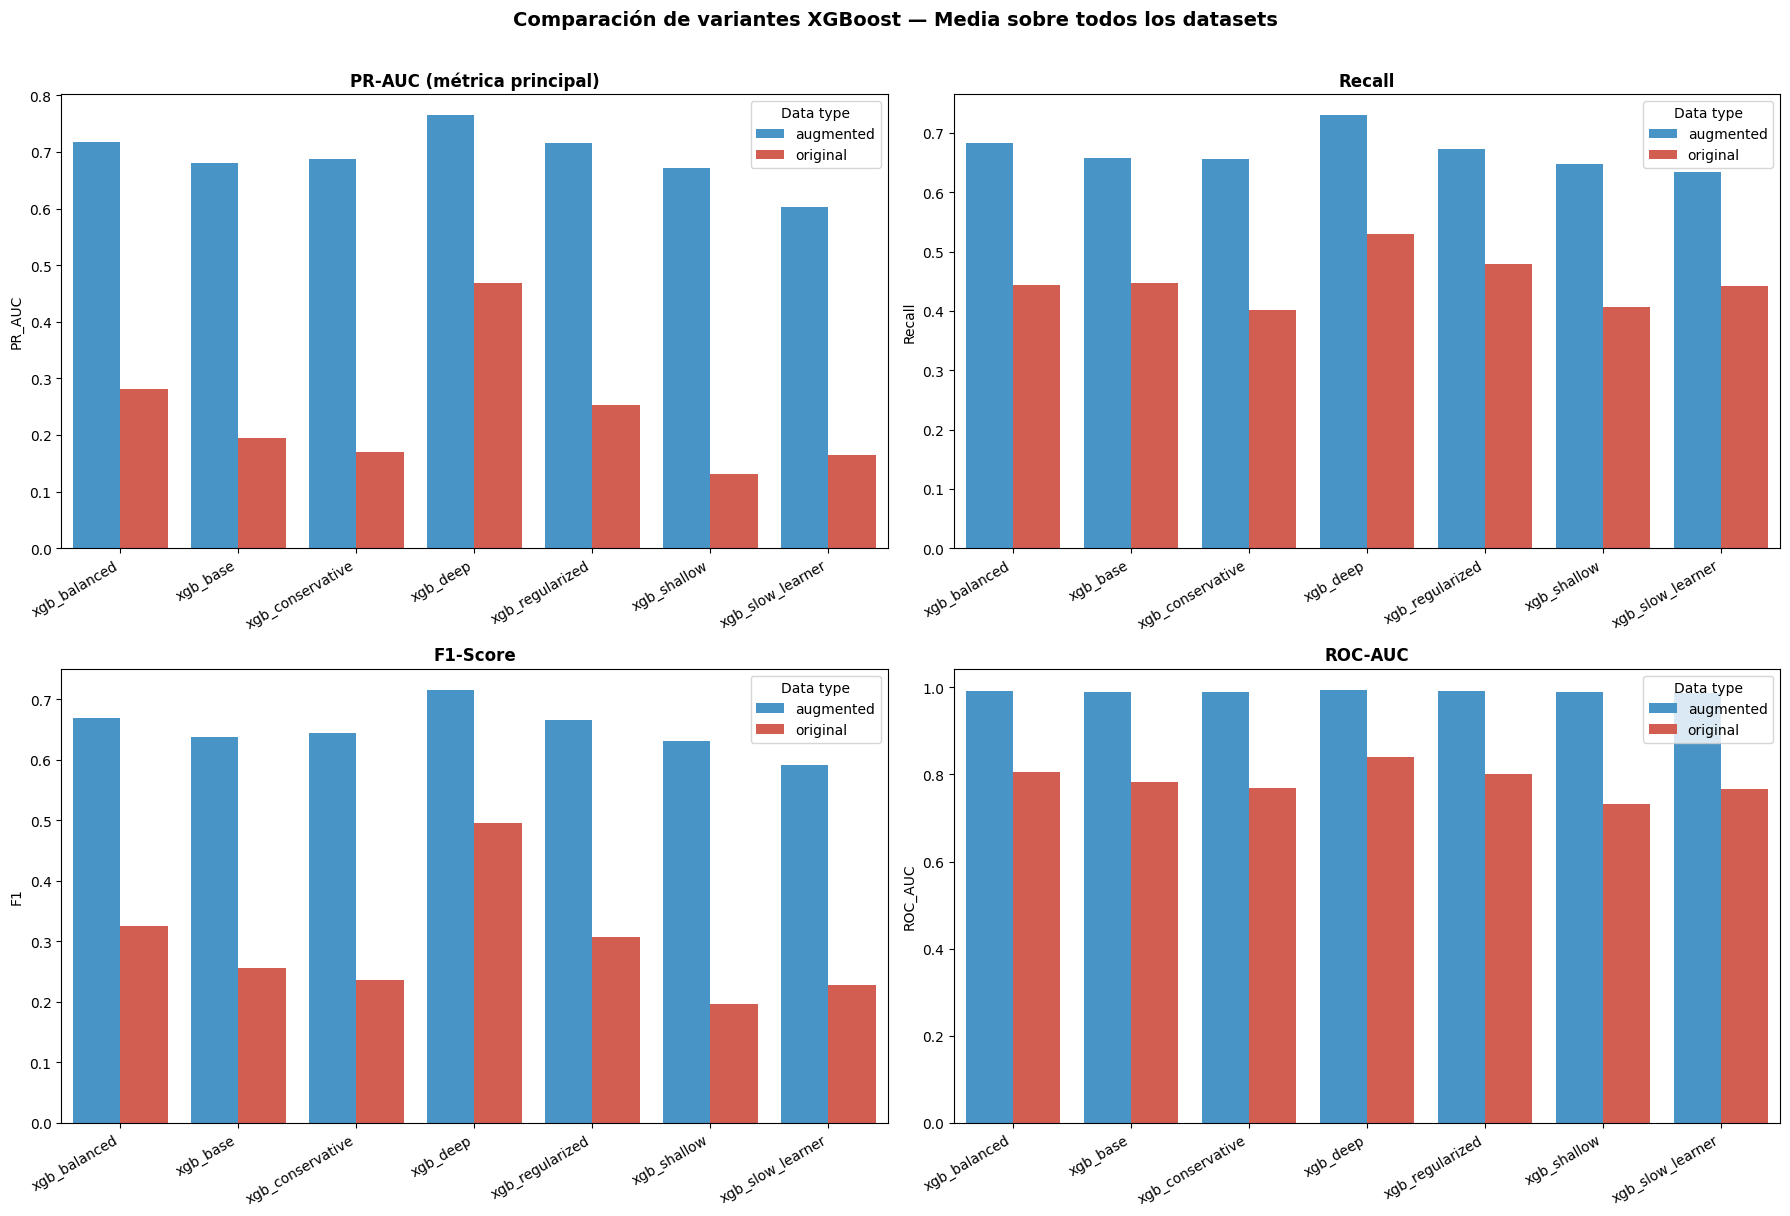

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics = ['PR_AUC', 'Recall', 'F1', 'ROC_AUC']
titles  = ['PR-AUC (métrica principal)', 'Recall', 'F1-Score', 'ROC-AUC']

for ax, metric, title in zip(axes.flat, metrics, titles):
    pivot = (
        df_res.groupby(['Variant', 'Data_Type'])[metric]
        .mean()
        .reset_index()
    )
    sns.barplot(data=pivot, x='Variant', y=metric, hue='Data_Type',
                palette={'augmented': '#3498db', 'original': '#e74c3c'}, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Data type')

plt.suptitle('Comparación de variantes XGBoost — Media sobre todos los datasets',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

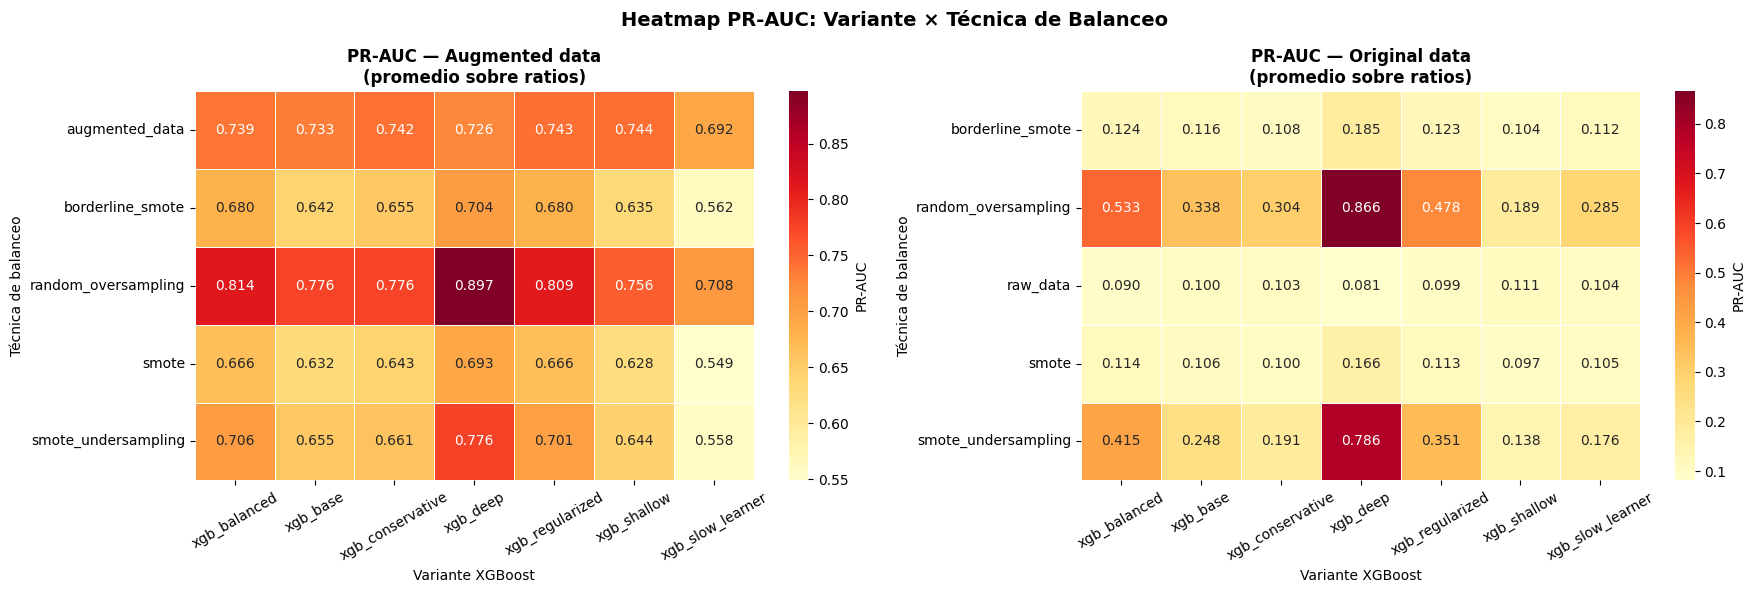

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, data_type in zip(axes, ['augmented', 'original']):
    sub = df_res[df_res['Data_Type'] == data_type]
    pivot = sub.groupby(['Variant', 'Technique'])['PR_AUC'].mean().reset_index()
    pivot_wide = pivot.pivot(index='Technique', columns='Variant', values='PR_AUC')
    sns.heatmap(pivot_wide, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'PR-AUC'})
    ax.set_title(f'PR-AUC — {data_type.capitalize()} data\n(promedio sobre ratios)',
                 fontweight='bold')
    ax.set_xlabel('Variante XGBoost')
    ax.set_ylabel('Técnica de balanceo')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Heatmap PR-AUC: Variante × Técnica de Balanceo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Análisis del Mejor Modelo Global
### 8.1 Matriz de confusión

Mejor combinación global (PR-AUC = 0.9484)
  Variante  : xgb_deep
  Data type : original
  Técnica   : random_oversampling
  Ratio     : 25
  Umbral    : 0.7264
  S3        : s3://poc-fraude-vishing/proyecto/modelos_xgb/original/xgb_deep/random_oversampling/25.pkl


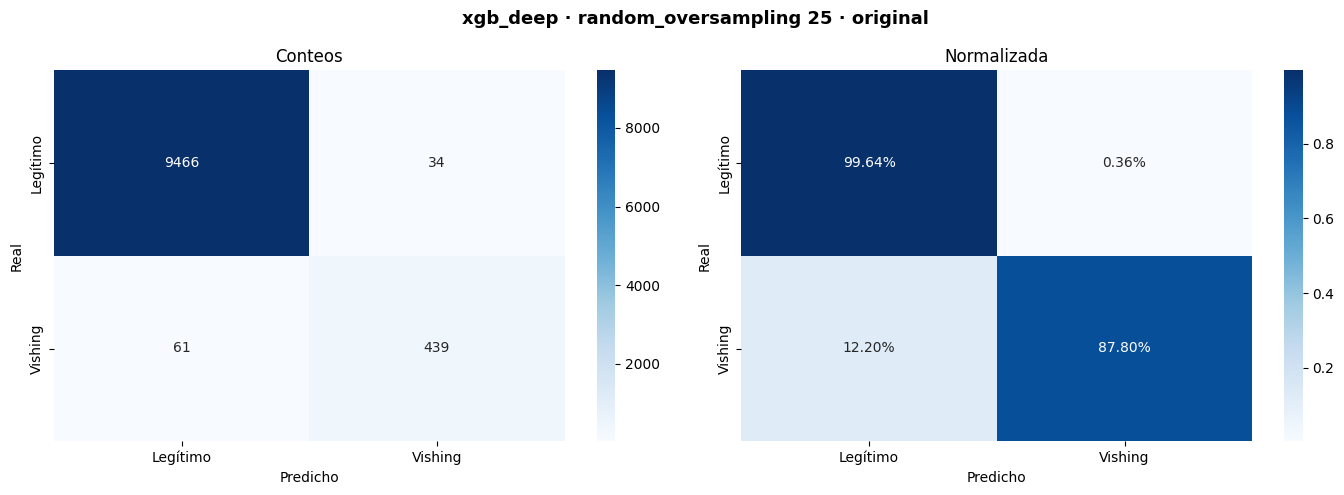


TN=9,466  FP=34  FN=61  TP=439
Recall    : 0.8780
Precision : 0.9281
F1        : 0.9024
PR-AUC    : 0.9484


In [18]:
best_row = df_res_sorted.iloc[0]
print(f"Mejor combinación global (PR-AUC = {best_row['PR_AUC']:.4f})")
print(f"  Variante  : {best_row['Variant']}")
print(f"  Data type : {best_row['Data_Type']}")
print(f"  Técnica   : {best_row['Technique']}")
print(f"  Ratio     : {best_row['Ratio']}")
print(f"  Umbral    : {best_row['Threshold']}")
print(f"  S3        : {best_row['S3_Path']}")

# Cargar wrapper desde S3
parsed   = urlparse(best_row['S3_Path'])
s3_key   = parsed.path.lstrip('/')
buf      = BytesIO()
s3_client.download_fileobj(BUCKET, s3_key, buf)
buf.seek(0)
best_wrapper = joblib.load(buf)

# Holdout correcto según data_type
if best_row['Data_Type'] == 'augmented':
    X_te, y_te = X_test_aug[best_wrapper.feature_names], y_test_aug
else:
    feat_ok = [f for f in best_wrapper.feature_names if f in X_test_orig.columns]
    X_te, y_te = X_test_orig[feat_ok], y_test_orig

y_prob_best = best_wrapper.model.predict_proba(X_te.values)[:, 1]
y_pred_best = (y_prob_best >= best_wrapper.threshold).astype(int)
cm = confusion_matrix(y_te, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legítimo', 'Vishing'], yticklabels=['Legítimo', 'Vishing'])
axes[0].set_title('Conteos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Legítimo', 'Vishing'], yticklabels=['Legítimo', 'Vishing'])
axes[1].set_title('Normalizada')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.suptitle(f"{best_row['Variant']} · {best_row['Technique']} {best_row['Ratio']} · {best_row['Data_Type']}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'Recall    : {tp/(tp+fn):.4f}')
print(f'Precision : {tp/(tp+fp):.4f}')
print(f'F1        : {2*tp/(2*tp+fp+fn):.4f}')
print(f'PR-AUC    : {average_precision_score(y_te, y_prob_best):.4f}')

### 8.2 Curva Precision-Recall y análisis de umbral

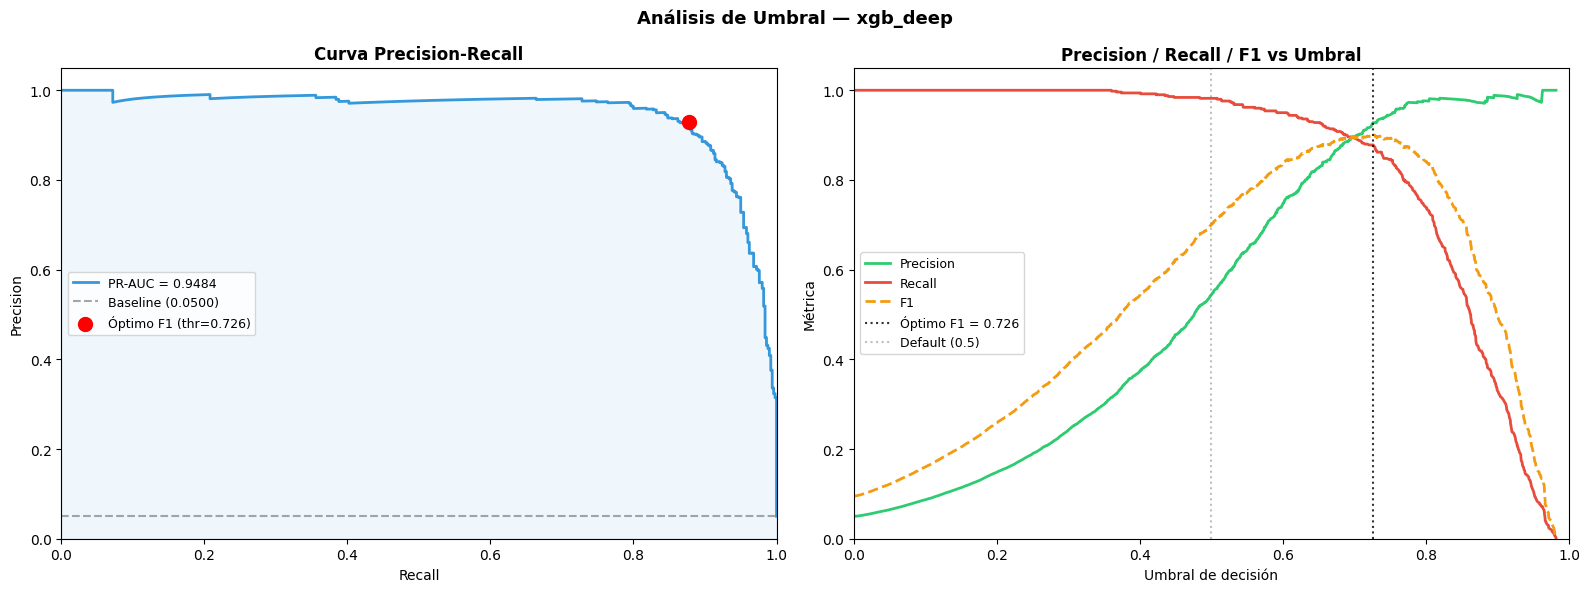

In [19]:
prec_c, rec_c, thr_c = precision_recall_curve(y_te, y_prob_best)
f1_c   = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
best_i = np.argmax(f1_c)
pr_auc = average_precision_score(y_te, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(rec_c, prec_c, color='#3498db', linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[0].fill_between(rec_c, prec_c, alpha=0.08, color='#3498db')
axes[0].axhline(y=y_te.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'Baseline ({y_te.mean():.4f})')
axes[0].scatter([rec_c[best_i]], [prec_c[best_i]], s=100, color='red', zorder=5,
                label=f'Óptimo F1 (thr={thr_c[best_i]:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

axes[1].plot(thr_c, prec_c[:-1], label='Precision', color='#2ecc71', linewidth=2)
axes[1].plot(thr_c, rec_c[:-1],  label='Recall',    color='#e74c3c', linewidth=2)
axes[1].plot(thr_c, f1_c,        label='F1',        color='#f39c12', linewidth=2, linestyle='--')
axes[1].axvline(x=thr_c[best_i], color='black', linestyle=':', alpha=0.8,
                label=f'Óptimo F1 = {thr_c[best_i]:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Precision / Recall / F1 vs Umbral', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.suptitle(f"Análisis de Umbral — {best_row['Variant']}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Feature Importance del mejor modelo

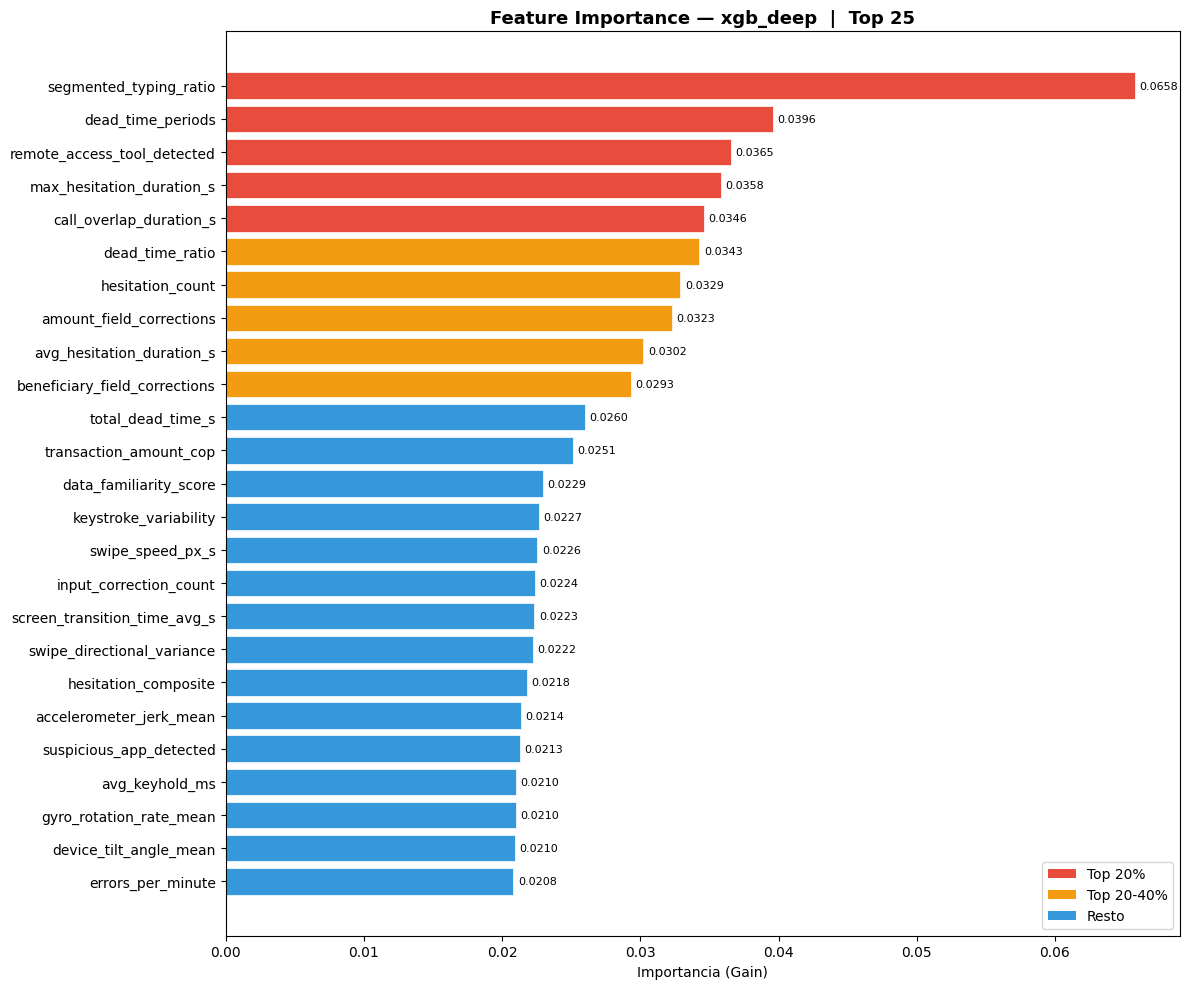

Top 15 features:
Feature                                   Importancia
-------------------------------------------------------
segmented_typing_ratio                         0.0658
dead_time_periods                              0.0396
remote_access_tool_detected                    0.0365
max_hesitation_duration_s                      0.0358
call_overlap_duration_s                        0.0346
dead_time_ratio                                0.0343
hesitation_count                               0.0329
amount_field_corrections                       0.0323
avg_hesitation_duration_s                      0.0302
beneficiary_field_corrections                  0.0293
total_dead_time_s                              0.0260
transaction_amount_cop                         0.0251
data_familiarity_score                         0.0229
keystroke_variability                          0.0227
swipe_speed_px_s                               0.0226


In [20]:
fi = pd.DataFrame({
    'feature'   : best_wrapper.feature_names,
    'importance': best_wrapper.model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))
top25   = fi.head(25)

q80 = top25['importance'].quantile(0.80)
q60 = top25['importance'].quantile(0.60)
colors = ['#e74c3c' if v >= q80 else '#f39c12' if v >= q60 else '#3498db'
          for v in top25['importance']]

ax.barh(range(len(top25)), top25['importance'].values,
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importancia (Gain)')
ax.set_title(f'Feature Importance — {best_row["Variant"]}  |  Top 25', fontweight='bold', fontsize=13)

for i, v in enumerate(top25['importance'].values):
    ax.text(v + top25['importance'].max() * 0.005, i, f'{v:.4f}', va='center', fontsize=8)

ax.legend(handles=[
    mpatches.Patch(facecolor='#e74c3c', label='Top 20%'),
    mpatches.Patch(facecolor='#f39c12', label='Top 20-40%'),
    mpatches.Patch(facecolor='#3498db', label='Resto'),
], loc='lower right')

plt.tight_layout()
plt.show()

print('Top 15 features:')
print(f'{"Feature":40s} {"Importancia":>12s}')
print('-' * 55)
for _, row in fi.head(15).iterrows():
    print(f"{row['feature']:40s} {row['importance']:12.4f}")

## 9. Resumen ejecutivo

In [21]:
print('=' * 70)
print('RESUMEN DE ENTRENAMIENTO')
print('=' * 70)
print(f'  Total modelos entrenados : {len(df_res)}')
print(f'  Variantes XGBoost        : {df_res["Variant"].nunique()}')
print(f'  Datasets aumentados      : {df_res[df_res["Data_Type"]=="augmented"]["Technique"].count() // df_res["Variant"].nunique()}')
print(f'  Datasets originales      : {df_res[df_res["Data_Type"]=="original"]["Technique"].count() // df_res["Variant"].nunique()}')
print(f'  Modelos en S3            : s3://{BUCKET}/{MODELS_PREFIX}/')
print()

for data_type in ['augmented', 'original']:
    sub  = df_res[df_res['Data_Type'] == data_type]
    best = sub.sort_values('PR_AUC', ascending=False).iloc[0]
    print(f'  Mejor {data_type:10s} — {best["Variant"]:20s} | {best["Technique"]:25s} | ratio={best["Ratio"]:4s}')
    print(f'    PR-AUC={best["PR_AUC"]:.4f}  Recall={best["Recall"]:.4f}  F1={best["F1"]:.4f}')
    print()

print('=' * 70)
print(f'  Mejor global → {best_row["Variant"]} / {best_row["Data_Type"]} / {best_row["Technique"]} / {best_row["Ratio"]}')
print(f'  PR-AUC={best_row["PR_AUC"]:.4f}  Recall={best_row["Recall"]:.4f}  F1={best_row["F1"]:.4f}')
print('=' * 70)

# Guardar tabla de resultados en S3
csv_buf = BytesIO()
df_res.sort_values('PR_AUC', ascending=False).to_csv(csv_buf, index=False)
csv_buf.seek(0)
results_key = f'{MODELS_PREFIX}/resultados_xgb_experimento.csv'
s3_client.upload_fileobj(csv_buf, BUCKET, results_key)
print(f'\nTabla de resultados guardada en: s3://{BUCKET}/{results_key}')

RESUMEN DE ENTRENAMIENTO
  Total modelos entrenados : 182
  Variantes XGBoost        : 7
  Datasets aumentados      : 13
  Datasets originales      : 13
  Modelos en S3            : s3://poc-fraude-vishing/proyecto/modelos_xgb/

  Mejor augmented  — xgb_deep             | random_oversampling       | ratio=25  
    PR-AUC=0.8989  Recall=0.8547  F1=0.8294

  Mejor original   — xgb_deep             | random_oversampling       | ratio=25  
    PR-AUC=0.9484  Recall=0.8780  F1=0.9024

  Mejor global → xgb_deep / original / random_oversampling / 25
  PR-AUC=0.9484  Recall=0.8780  F1=0.9024

Tabla de resultados guardada en: s3://poc-fraude-vishing/proyecto/modelos_xgb/resultados_xgb_experimento.csv
